In [1]:
# Tree length, and number of leaves in host and parasite trees
from Bio import Phylo
from io import StringIO
import re
def load_tree(newick_str):

    return Phylo.read(StringIO(newick_str), "newick")

def get_tree_stats(tree):
    num_leaves = len(tree.get_terminals())
    total_branch_length = sum(clade.branch_length for clade in tree.get_nonterminals() + tree.get_terminals() if clade.branch_length)
    max_depth = max(tree.depths().values())
    num_branches = len(tree.get_nonterminals()) + len(tree.get_terminals()) - 1  # Total branches in the tree
    tree_stats = {
        "num_leaves": num_leaves,
        "total_branch_length": total_branch_length,
        "max_depth": max_depth,
        "num_branches": num_branches
    }
    return tree_stats

def host_tree_branches_list(datasets):
    values = []
    for dataset in datasets:
        if "host_tree_stats" in dataset:
            values.append(dataset["host_tree_stats"]["num_branches"])
    return values


def parasite_tree_branches_list(datasets):
    values = []
    for dataset in datasets:
        if "parasite_tree_stats" in dataset:
            values.append(dataset["parasite_tree_stats"]["num_branches"])
    return values


def host_tree_length_list(datasets):
    values = []
    for dataset in datasets:
        if "host_tree_stats" in dataset:
            values.append(dataset["host_tree_stats"]["max_depth"])
    return values


def parasite_tree_length_list(datasets):
    values = []
    for dataset in datasets:
        if "parasite_tree_stats" in dataset:
            values.append(dataset["parasite_tree_stats"]["max_depth"])
    return values


def host_tree_leaves_list(datasets):
    values = []
    for dataset in datasets:
        if "host_tree_stats" in dataset:
            values.append(dataset["host_tree_stats"]["num_leaves"])
    return values


def parasite_tree_leaves_list(datasets):
    values = []
    for dataset in datasets:
        if "parasite_tree_stats" in dataset:
            values.append(dataset["parasite_tree_stats"]["num_leaves"])
    return values

def host_vs_parasite_list(datasets):
    differences = []
    for dataset in datasets:
        if 'host_tree_stats' in dataset and 'parasite_tree_stats' in dataset:
            host_depth = dataset['host_tree_stats']['num_branches']
            parasite_depth = dataset['parasite_tree_stats']['num_branches']
            differences.append(host_depth - parasite_depth)
    return differences

def host_vs_parasite_list_leaves(datasets):
    differences = []
    for dataset in datasets:
        if 'host_tree_stats' in dataset and 'parasite_tree_stats' in dataset:
            host_depth = dataset['host_tree_stats']['num_leaves']
            parasite_depth = dataset['parasite_tree_stats']['num_leaves']
            differences.append(host_depth - parasite_depth)
    return differences
    
def host_vs_parasite_list_length(datasets):
    differences = []
    for dataset in datasets:
        if 'host_tree_stats' in dataset and 'parasite_tree_stats' in dataset:
            host_depth = dataset['host_tree_stats']['max_depth']
            parasite_depth = dataset['parasite_tree_stats']['max_depth']
            differences.append(host_depth - parasite_depth)
    return differences

def average_host_tree_depth(datasets): #num branches
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_depth += dataset['host_tree_stats']['num_branches']
            count += 1
    return total_depth / count if count > 0 else 0


def average_parasite_tree_depth(datasets):#num branches
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_depth += dataset['parasite_tree_stats']['num_branches']
            count += 1
    return total_depth / count if count > 0 else 0



def average_host_tree_length(datasets): # max depth
    total_length = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_length += dataset['host_tree_stats']['max_depth']
            count += 1
    return total_length / count if count > 0 else 0


def average_parasite_tree_length(datasets):# max depth
    total_length = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_length += dataset['parasite_tree_stats']['max_depth']
            count += 1
    return total_length / count if count > 0 else 0


def average_host_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_leaves += dataset['host_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0

def average_parasite_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_leaves += dataset['parasite_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0 

# extract associations and count the number of associations per dataset. Measure the average
def average_associations_per_dataset(datasets):
    total_associations = 0
    count = 0
    for dataset in datasets:
        if 'associations' in dataset:
            total_associations += len(dataset['associations'])
            count += 1
    return total_associations / count if count > 0 else 0

# phylogenetic tree metrics, such as cherry index, Sackin index, and Colless' index
import pandas as pd
from ete3 import Tree
import matplotlib.pyplot as plt
import seaborn as sns

def count_cherries(tree):
    count = 0
    for node in tree.traverse():
        if not node.is_leaf():
            children = node.get_children()
            if len(children) == 2 and all(child.is_leaf() for child in children):
                count += 1
    return count

def cherry_index(tree):
    cherries = count_cherries(tree)
    leaves = len(tree.get_leaves())
    cherry_index = (cherries / leaves if leaves > 0 else 0)*2
    return cherry_index
 

def sackin_index(tree):
    sacking_index = sum(tree.get_distance(leaf) for leaf in tree.iter_leaves())
    leaves = len(tree.get_leaves())
    sacking_index = sacking_index / (leaves**2) if leaves > 0 else 0
    return sacking_index

def sackin_index_topology(tree):
    sacking_index = sum(tree.get_distance(leaf,topology_only = True) for leaf in tree.iter_leaves())
    leaves = len(tree.get_leaves())
    sacking_index = sacking_index / (leaves**2) if leaves > 0 else 0
    return sacking_index

def colless_index_normalized(tree):
    def imbalance(node):
        if node.is_leaf():
            return 0
        children = node.get_children()
        if len(children) != 2:
            # allow multifurcations
            return sum(imbalance(c) for c in children)
        left = len(children[0].get_leaves())
        right = len(children[1].get_leaves())
        return abs(left - right) + imbalance(children[0]) + imbalance(children[1])

    C = imbalance(tree)
    n = len(tree.get_leaves())

    # maximum Colless index for binary tree with n leaves
    C_max = (n - 1) * (n - 2) / 2 if n >= 3 else 0

    return C / C_max if C_max > 0 else 0

#find. normalized version of colless index (divide by (n-1)2)

def compute_tree_metrics(datasets, model_name="Model"):
    results = []
    for ds in datasets:
        host_nwk = ds['host_newick']
        parasite_nwk = ds['parasite_newick']

        if not host_nwk.strip().endswith(';'):
            host_nwk += ';'
        if not parasite_nwk.strip().endswith(';'):
            parasite_nwk += ';'

        try:
            h_tree = Tree(host_nwk, format=1)
            p_tree = Tree(parasite_nwk, format=1)
        except Exception as e:
            print(f"[ERROR] Failed to parse trees in file: {ds['filename']} — {e}")
            continue

        results.append({
            'model': model_name,
            'filename': ds['filename'],
            'host_leaves': len(h_tree.get_leaves()),
            'parasite_leaves': len(p_tree.get_leaves()),
            'cherry_index_host': cherry_index(h_tree),
            'cherry_index_parasite': cherry_index(p_tree),
            'sackin_index_host': sackin_index(h_tree),
            'sackin_index_parasite': sackin_index(p_tree),
            'sackin_index_topology_host': sackin_index_topology(h_tree),
            'sackin_index_topology_parasite': sackin_index_topology(p_tree),
            'colless_index_host': colless_index_normalized(h_tree),
            'colless_index_parasite': colless_index_normalized(p_tree),
        })
    return pd.DataFrame(results)



def plot_metric_comparison_paired(df_all, base_metric_name, title=None):
    host_col = f"{base_metric_name}_host"
    parasite_col = f"{base_metric_name}_parasite"

    # Melt the data to long format
    df_melted = df_all.melt(
        id_vars=['model'],
        value_vars=[host_col, parasite_col],
        var_name='metric_type',
        value_name='value'
    )

    # Clean up metric_type for legend (host / parasite)
    df_melted['metric_type'] = df_melted['metric_type'].apply(
        lambda x: 'Host' if 'host' in x else 'Parasite'
    )

    # Plot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_melted, x='model', y='value', hue='metric_type', errorbar='sd')

    plt.title(title or f'{base_metric_name.replace("_", " ").title()} (Host vs Parasite)')
    plt.ylabel(base_metric_name.replace('_', ' ').title())
    plt.xlabel('Model')
    plt.legend(title='Tree Type')
    plt.tight_layout()
    plt.show()
    
# extract reconcilation data
def extract_sim_stats(datasets):

    extracted = []

    for data in datasets:
        stats = data.get('sim_stats', {})
        fname = data.get('filename', 'unknown')

        # --- Case 1: new event-based format ---
        if any(k in stats for k in ["Cospeciations", "Host_Speciations", "Symbiont_Speciations"]):
            extracted.append({
                'filename': fname,
                'Total_Events': stats.get('Total_Events'),
                'Cospeciations': stats.get('Cospeciations'),
                'Host_Speciations': stats.get('Host_Speciations'),
                'Symbiont_Speciations': stats.get('Symbiont_Speciations'),
                'Host_Extinctions': stats.get('Host_Extinctions'),
                'Symbiont_Extinctions': stats.get('Symbiont_Extinctions'),
                'Host_Spread_Switches': stats.get('Host_Spread_Switches'),
            })

        elif any(k in stats for k in ["Expected", "Observed", "Frequencies"]):
            def parse_list(s):
                if isinstance(s, str):
                    s = s.strip("[]")
                    if not s:
                        return []
                    return [float(x) for x in s.split(",")]
                elif isinstance(s, list):
                    return s
                return []

            extracted.append({
                'filename': fname,
                'Probabilities': parse_list(stats.get('Probabilities', '')),
                'Frequencies': parse_list(stats.get('Frequencies', '')),
            })

        # --- Case 3: no recognizable stats ---
        else:
            extracted.append({'filename': fname, **stats})

    return extracted


def expand_event_columns(sim_stats_list):
    records = []
    event_names = ["Cospeciation", "Duplication", "Switch", "Loss"]

    for entry in sim_stats_list:
        fname = entry.get("filename")
        probs = entry.get("Probabilities", [None]*4)
        freqs = entry.get("Frequencies", [None]*4)

        # Handle cases with missing or shorter lists
        probs = list(probs) + [None]*(4 - len(probs))
        freqs = list(freqs) + [None]*(4 - len(freqs))

        record = {"filename": fname}
        for i, event in enumerate(event_names):
            record[f"Prob_{event}"] = probs[i]
            record[f"Freq_{event}"] = freqs[i]
        records.append(record)

    return pd.DataFrame(records)


def flatten_sim_stats(sim_stats_list):

    flattened = []

    for entry in sim_stats_list:
        record = {}
        record["filename"] = entry.get("filename", "unknown")

        for key, value in entry.items():
            if key == "filename":
                continue

            # If value is a list or tuple → expand it
            if isinstance(value, (list, tuple)):
                for i, v in enumerate(value):
                    record[f"{key}_{i}"] = v
            else:
                record[key] = value

        flattened.append(record)

    df = pd.DataFrame(flattened)
    cols = ["filename"] + [c for c in df.columns if c != "filename"]
    return df[cols]


In [2]:
import os
import re

import os
import re

TREE_LINE_RE = re.compile(r"^TREE\b", re.IGNORECASE)          # matches "TREE ..." at line start
BEGIN_RE = re.compile(r"^BEGIN\s+(\w+)", re.IGNORECASE)       # BEGIN HOST; / BEGIN PARASITE; / BEGIN DISTRIBUTION;
END_BLOCK_RE = re.compile(r"^(ENDBLOCK|END)\b", re.IGNORECASE)

def parse_treeducken_file(filepath, *, verbose=False):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}

    block = None  # "HOST" | "PARASITE" | "DISTRIBUTION" | None

    with open(filepath, "r") as f:
        lines = f.readlines()

    def log(msg):
        if verbose:
            print(f"[{os.path.basename(filepath)}] {msg}")

    for raw in lines:
        stripped = raw.strip()
        if not stripped:
            continue

        # BEGIN <block>
        m = BEGIN_RE.match(stripped)
        if m:
            block = m.group(1).upper()
            continue

        # END / ENDBLOCK
        if END_BLOCK_RE.match(stripped):
            block = None
            continue

        # HOST tree
        if block == "HOST" and TREE_LINE_RE.match(stripped):
            if "=" not in stripped:
                log(f"HOST TREE line missing '=': {stripped!r}")
                continue
            _, rhs = stripped.split("=", 1)
            host_newick = rhs.strip().rstrip(";").strip()
            continue

        # PARASITE tree
        if block == "PARASITE" and TREE_LINE_RE.match(stripped):
            if "=" not in stripped:
                log(f"PARASITE TREE line missing '=': {stripped!r}")
                continue
            _, rhs = stripped.split("=", 1)
            parasite_newick = rhs.strip().rstrip(";").strip()
            continue

        # DISTRIBUTION mappings
        if block == "DISTRIBUTION" and ":" in stripped:
            left, sep, right = stripped.partition(":")
            parasite = left.strip()
            host = right.strip()
            if not parasite or not host:
                log(f"Bad distribution line: {stripped!r}")
                continue
            associations.append((parasite, host))
            continue

    # Stats at the end (Key Value)
    stat_pattern = re.compile(r"^([A-Za-z_/]+[\w\s/\-]*?)\s+([-\d.eE+]+|NaN)$")
    for raw in reversed(lines):
        line = raw.strip()
        if not line:
            continue
        match = stat_pattern.match(line)
        if match:
            key = match.group(1).strip().replace(" ", "_").replace("/", "_")
            val_str = match.group(2).strip()
            sim_stats[key] = None if val_str.lower() == "nan" else float(val_str)

    return {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats,
    }
def parse_all_treeducken_in_folder(folder_path, *, verbose=False):
    datasets = []
    for filename in os.listdir(folder_path):
        if not filename.endswith(".tgl"):
            continue
        full_path = os.path.join(folder_path, filename)
        try:
            datasets.append(parse_treeducken_file(full_path, verbose=verbose))
        except Exception as e:
            print(f"Error parsing {filename}: {e}")
    return datasets

# Cospeciation 0

In [7]:
datasets_treeducken_cosp0 = parse_all_treeducken_in_folder('/Users/gabriele/Co-phyloformer/generate_treeducken/generated_trees/extreme_cosp_data/cosp_0')
datasets_treeducken_cosp0

[{'filename': 'Dataset638543.tgl',
  'host_newick': '(H1:1.619525407,((H2:0.6846122081,3:0.2881087883):0.5020725003,((H5:0.4025304456,6:0.04331044326):0.2330322478,H4:0.6355626935):0.551122015):0.4328406988):0.8804745927',
  'parasite_newick': '((1:1.143361725,2:0.3385784521):0.3707668577,(((P5:0.2912645024,P6:0.2912645024):0.5386905377,P4:0.8299550401):0.1307472686,P3:0.9607023087):1.17077724):0.3685204514',
  'associations': [('P3', 'H1'), ('P4', 'H1'), ('P5', 'H1'), ('P6', 'H1')],
  'sim_stats': {'Total_Events': 14.0,
   'Sim_time': 2.5,
   'Parasite_num_leaves': 6.0,
   'Host_num_leaves': 6.0,
   'Parafit_P-value': 1.0,
   'Parafit_Stat': 1.977616e-31,
   'Extirpations': 0.0,
   'Dispersals': 0.0,
   'Host_Spreads_switches': 0.0,
   'Symbiont_Extinctions': 0.1428571,
   'Symbiont_Speciations': 0.3571429,
   'Host_Extinctions': 0.1428571,
   'Host_Speciations': 0.3571429,
   'Cospeciations': 0.0}},
 {'filename': 'Dataset384881.tgl',
  'host_newick': '((H3:0.194984561,H4:0.194984561)

In [8]:
for dataset in datasets_treeducken_cosp0:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_cosp0)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_cosp0)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_cosp0)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_cosp0)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_treeducken_cosp0)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_cosp0)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 7.443060367067148
Average parasite tree depth (# branches): 8.988280386231297
Average host tree length (max depth): 1.9247070097214993
Average parasite tree length (max depth): 1.924707009721291
Average number of leaves in host trees: 4.721530183533574
Average number of leaves in parasite trees: 5.494140193115649


In [9]:
avg_association = average_associations_per_dataset(datasets_treeducken_cosp0)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_cosp0)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_cosp0)
print(f"Min number of associations in a dataset: {min_associations}")


Average number of associations per dataset: 8.328849414019311
Max number of associations in a dataset: 149
Min number of associations in a dataset: 2


# Cospeciation 1

In [3]:
datasets_treeducken_cosp1 = parse_all_treeducken_in_folder('/Users/gabriele/Co-phyloformer/generate_treeducken/generated_trees/extreme_cosp_data/cosp_1')
datasets_treeducken_cosp1

[{'filename': 'Dataset636208.tgl',
  'host_newick': '(H1:0.556601156,(H2:0.2908801749,H3:0.2908801749):0.2657209811):1.943398844',
  'parasite_newick': '(P1:0.556601156,(P2:0.2908801749,P3:0.2908801749):0.2657209811):1.943398844',
  'associations': [('P1', 'H1'), ('P2', 'H2'), ('P3', 'H3')],
  'sim_stats': {'Total_Events': 2.0,
   'Sim_time': 2.5,
   'Parasite_num_leaves': 3.0,
   'Host_num_leaves': 3.0,
   'Parafit_P-value': 0.12,
   'Parafit_Stat': 0.621134,
   'Extirpations': 0.0,
   'Dispersals': 0.0,
   'Host_Spreads_switches': 0.0,
   'Symbiont_Extinctions': 0.0,
   'Symbiont_Speciations': 0.0,
   'Host_Extinctions': 0.0,
   'Host_Speciations': 0.0,
   'Cospeciations': 1.0}},
 {'filename': 'Dataset667721.tgl',
  'host_newick': '((H2:0.01269144022,H3:0.01269144022):0.5783638055,H1:0.5910552457):0.9089447543',
  'parasite_newick': '((P2:0.01269144022,P3:0.01269144022):0.5783638055,P1:0.5910552457):0.9089447543',
  'associations': [('P1', 'H1'), ('P2', 'H2'), ('P3', 'H3')],
  'sim_s

In [4]:
for dataset in datasets_treeducken_cosp1:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_cosp1)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_cosp1)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_cosp1)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_cosp1)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_treeducken_cosp1)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_cosp1)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 2.6191155492154063
Average parasite tree depth (# branches): 2.6191155492154063
Average host tree length (max depth): 1.6219686162383744
Average parasite tree length (max depth): 1.6219686162383744
Average number of leaves in host trees: 2.309557774607703
Average number of leaves in parasite trees: 2.309557774607703


In [5]:
avg_association = average_associations_per_dataset(datasets_treeducken_cosp1)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_cosp1)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_cosp1)
print(f"Min number of associations in a dataset: {min_associations}")


Average number of associations per dataset: 2.309557774607703
Max number of associations in a dataset: 9
Min number of associations in a dataset: 2


# Compare trees 

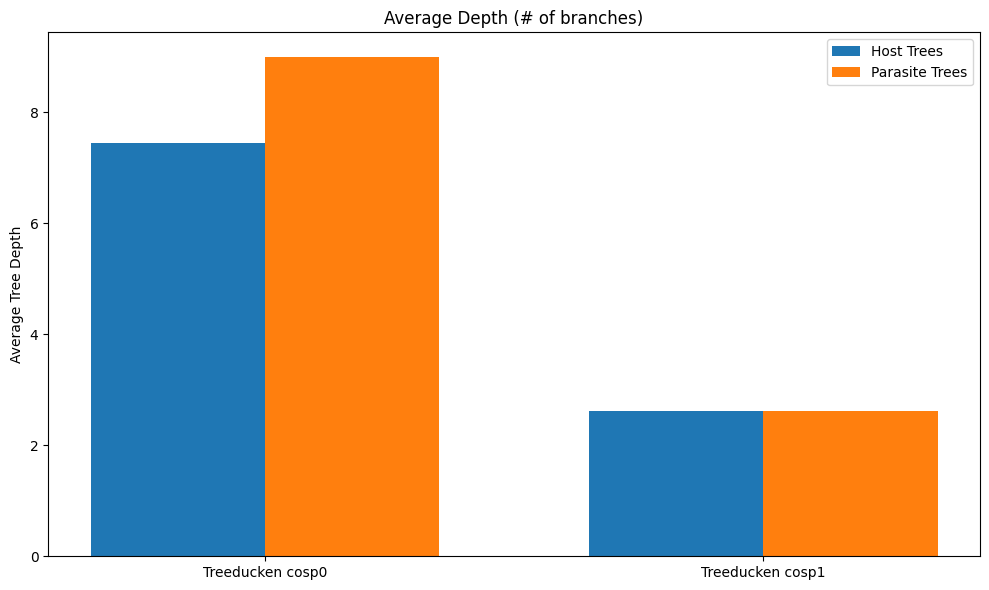

In [10]:
host_depths = [
    average_host_tree_depth(datasets_treeducken_cosp0),
    average_host_tree_depth(datasets_treeducken_cosp1)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_treeducken_cosp0),
    average_parasite_tree_depth(datasets_treeducken_cosp1)
]

# Plotting
labels = ['Treeducken cosp0', 'Treeducken cosp1']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Depth')
plt.title('Average Depth (# of branches)')
plt.legend()
plt.tight_layout()
plt.show()

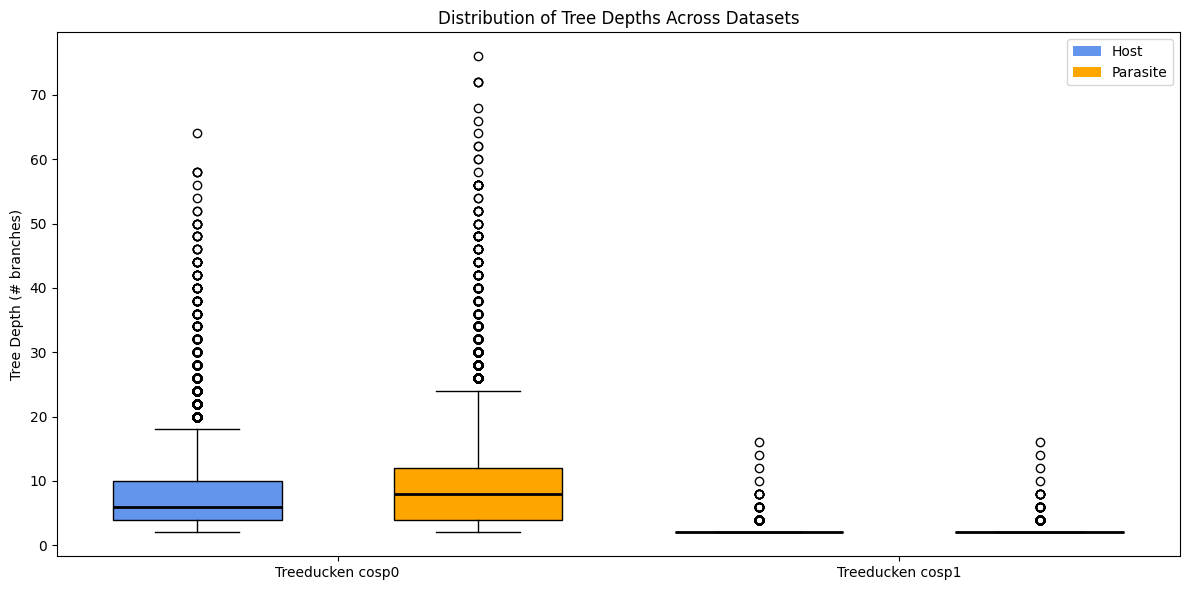

In [11]:
import matplotlib.pyplot as plt

# Collect LISTS (not averages!)
host_depths = [
    host_tree_branches_list(datasets_treeducken_cosp0),
    host_tree_branches_list(datasets_treeducken_cosp1),
]

parasite_depths = [
    parasite_tree_branches_list(datasets_treeducken_cosp0),
    parasite_tree_branches_list(datasets_treeducken_cosp1),
]

labels = ['Treeducken cosp0', 'Treeducken cosp1']

plt.figure(figsize=(12, 6))

# Host trees boxplot (left)
host_bp = plt.boxplot(
    host_depths,
    positions=[i*2 for i in range(len(labels))],
    widths=0.6,
    patch_artist=True
)

# Parasite trees boxplot (right)
parasite_bp = plt.boxplot(
    parasite_depths,
    positions=[i*2 + 1 for i in range(len(labels))],
    widths=0.6,
    patch_artist=True
)

# Color the boxes
for box in host_bp['boxes']:
    box.set(facecolor='cornflowerblue')  # blue

for box in parasite_bp['boxes']:
    box.set(facecolor='orange')          # orange
    
for median in host_bp['medians']:
    median.set(color='black', linewidth=2)

for median in parasite_bp['medians']:
    median.set(color='black', linewidth=2)

# x-ticks centered between pairs
plt.xticks([i*2 + 0.5 for i in range(len(labels))], labels)

plt.ylabel("Tree Depth (# branches)")
plt.title("Distribution of Tree Depths Across Datasets")

# Legend handles
from matplotlib.patches import Patch
plt.legend(
    handles=[
        Patch(facecolor='cornflowerblue', label='Host'),
        Patch(facecolor='orange', label='Parasite')
    ],
    loc='upper right'
)

plt.tight_layout()
plt.show()

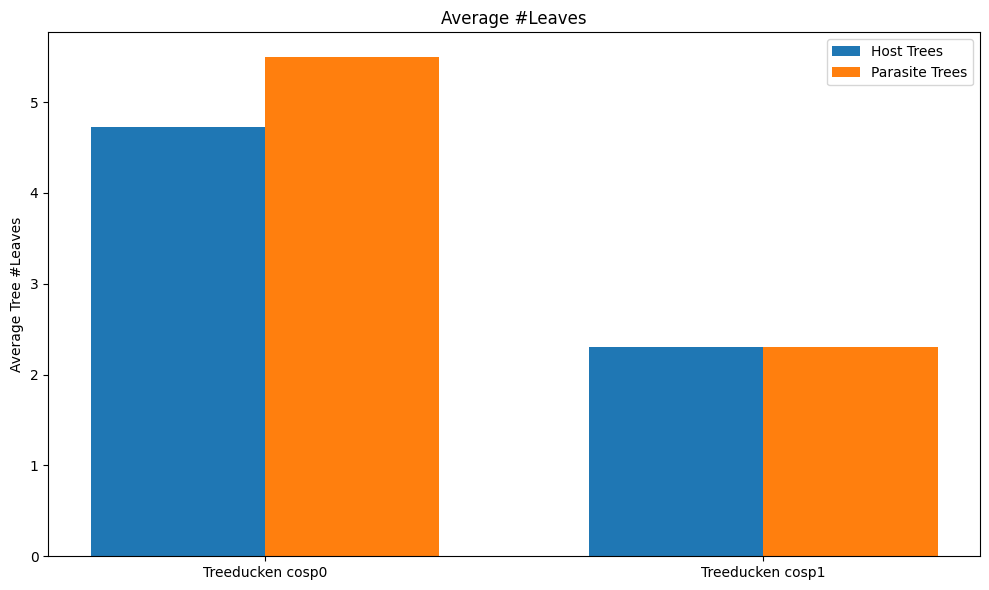

In [13]:
host_leaves = [
    average_host_tree_leaves(datasets_treeducken_cosp0),
    average_host_tree_leaves(datasets_treeducken_cosp1)
]

# Compute average depths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_treeducken_cosp0),
    average_parasite_tree_leaves(datasets_treeducken_cosp1)
]

# Plotting
labels = ['Treeducken cosp0', 'Treeducken cosp1']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree #Leaves')
plt.title('Average #Leaves')
plt.legend()
plt.tight_layout()
plt.show()

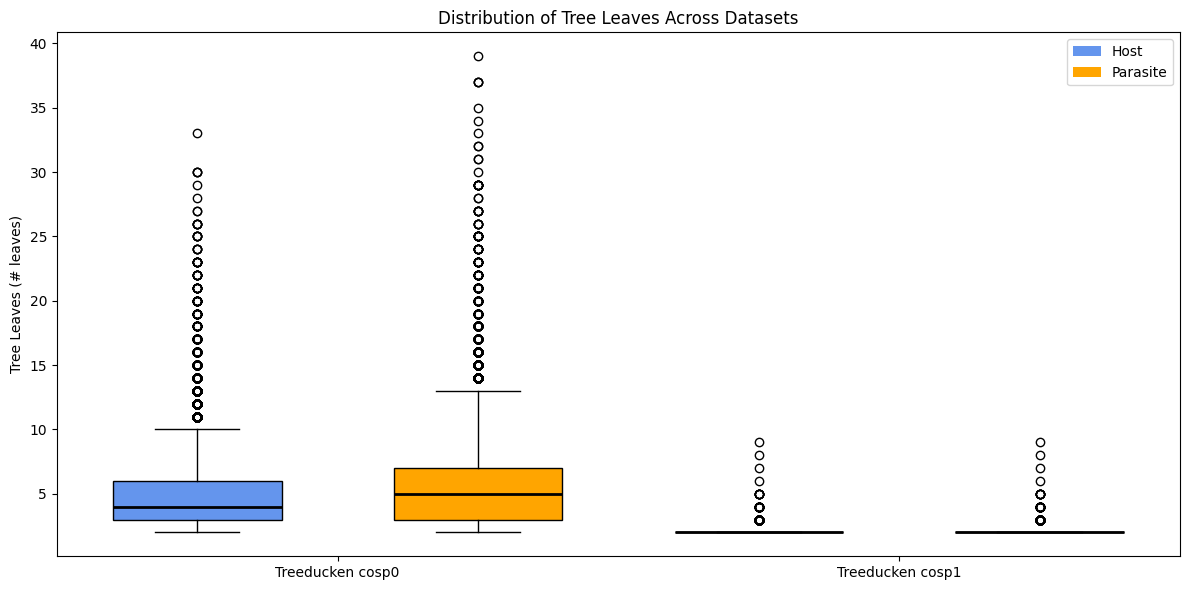

In [14]:
import matplotlib.pyplot as plt

# Collect LISTS (not averages!)
host_depths = [
    host_tree_leaves_list(datasets_treeducken_cosp0),
    host_tree_leaves_list(datasets_treeducken_cosp1),
]

parasite_depths = [
    parasite_tree_leaves_list(datasets_treeducken_cosp0),
    parasite_tree_leaves_list(datasets_treeducken_cosp1),
]

labels = ['Treeducken cosp0', 'Treeducken cosp1']
plt.figure(figsize=(12, 6))

# Host trees boxplot (left)
host_bp = plt.boxplot(
    host_depths,
    positions=[i*2 for i in range(len(labels))],
    widths=0.6,
    patch_artist=True
)

# Parasite trees boxplot (right)
parasite_bp = plt.boxplot(
    parasite_depths,
    positions=[i*2 + 1 for i in range(len(labels))],
    widths=0.6,
    patch_artist=True
)

# Color the boxes
for box in host_bp['boxes']:
    box.set(facecolor='cornflowerblue')  # blue

for box in parasite_bp['boxes']:
    box.set(facecolor='orange')          # orange

# Color median lines
for median in host_bp['medians']:
    median.set(color='black', linewidth=2)

for median in parasite_bp['medians']:
    median.set(color='black', linewidth=2)

# x-ticks centered between pairs
plt.xticks([i*2 + 0.5 for i in range(len(labels))], labels)

plt.ylabel("Tree Leaves (# leaves)")
plt.title("Distribution of Tree Leaves Across Datasets")

# Legend handles
from matplotlib.patches import Patch
plt.legend(
    handles=[
        Patch(facecolor='cornflowerblue', label='Host'),
        Patch(facecolor='orange', label='Parasite')
    ],
    loc='upper right'
)

plt.tight_layout()
plt.show()

/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_3471/336112170.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, patch_artist=True)


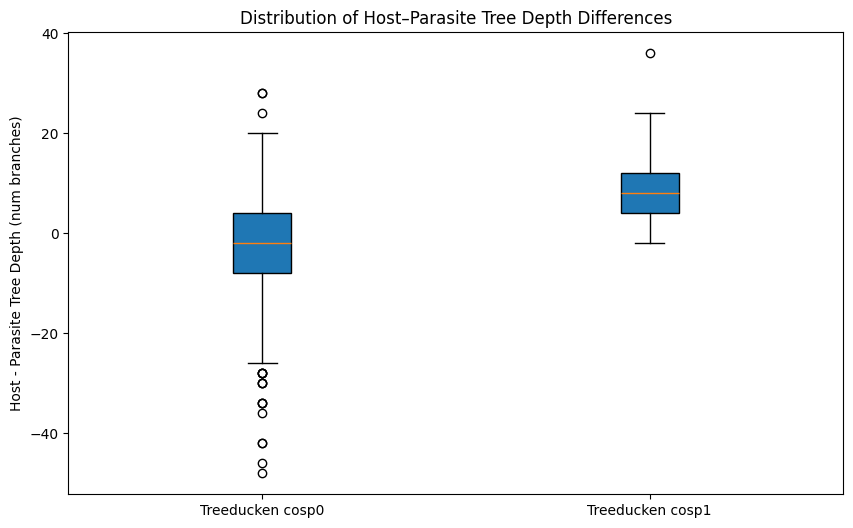

In [150]:
# Host vs pparasite dataset comparison
diffs = [
    host_vs_parasite_list(datasets_treeducken_cosp0),
    host_vs_parasite_list(datasets_treeducken_cosp1),
]

labels = ['Treeducken cosp0', 'Treeducken cosp1']

plt.figure(figsize=(10,6))
plt.boxplot(diffs, labels=labels, patch_artist=True)
plt.ylabel("Host - Parasite Tree Depth (num branches)")
plt.title("Distribution of Host–Parasite Tree Depth Differences")
plt.show()

/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_3471/1697050838.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, patch_artist=True)


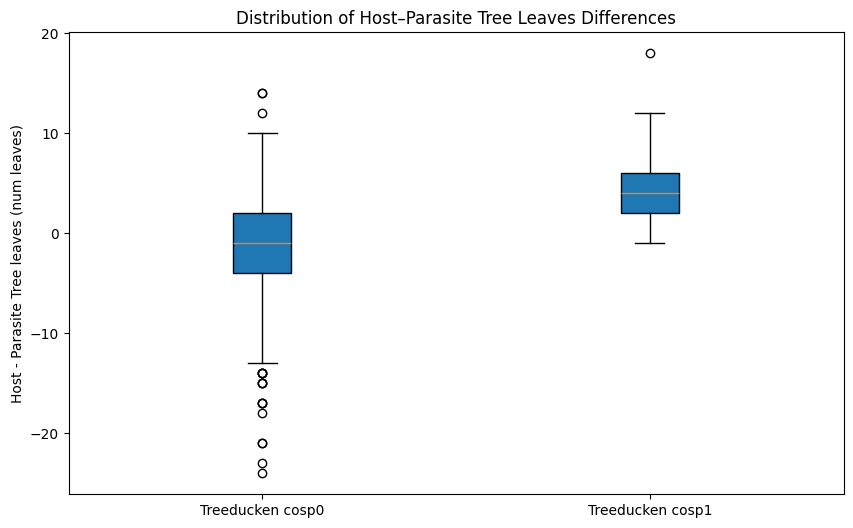

In [151]:
# Host vs pparasite dataset comparison
diffs = [
    host_vs_parasite_list_leaves(datasets_treeducken_cosp0),
    host_vs_parasite_list_leaves(datasets_treeducken_cosp1),
]

labels = ['Treeducken cosp0', 'Treeducken cosp1']

plt.figure(figsize=(10,6))
plt.boxplot(diffs, labels=labels, patch_artist=True)
plt.ylabel("Host - Parasite Tree leaves (num leaves)")
plt.title("Distribution of Host–Parasite Tree Leaves Differences")
plt.show()

/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_3471/3769388012.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(diffs, labels=labels, patch_artist=True)


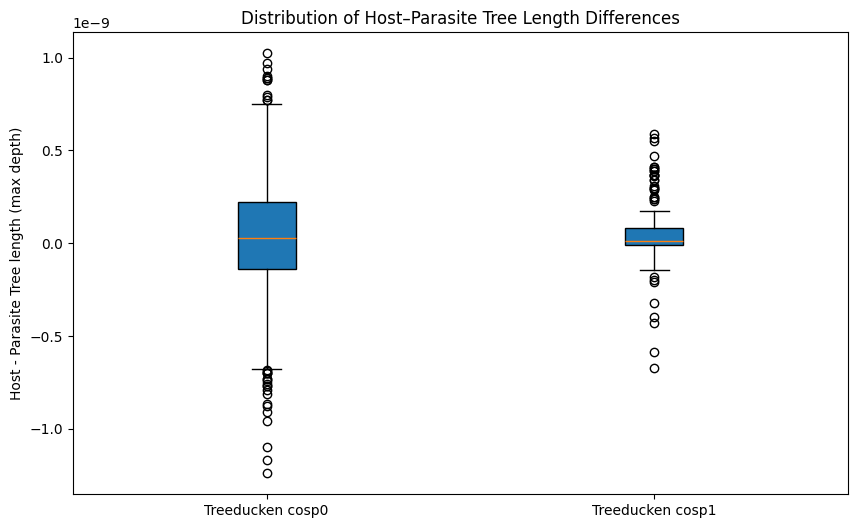

In [152]:
# Host vs pparasite dataset comparison
diffs = [
    host_vs_parasite_list_length(datasets_treeducken_cosp0),
    host_vs_parasite_list_length(datasets_treeducken_cosp1),
]

labels = ['Treeducken cosp0', 'Treeducken cosp1']

plt.figure(figsize=(10,6))
plt.boxplot(diffs, labels=labels, patch_artist=True)
plt.ylabel("Host - Parasite Tree length (max depth)")
plt.title("Distribution of Host–Parasite Tree Length Differences")
plt.show()

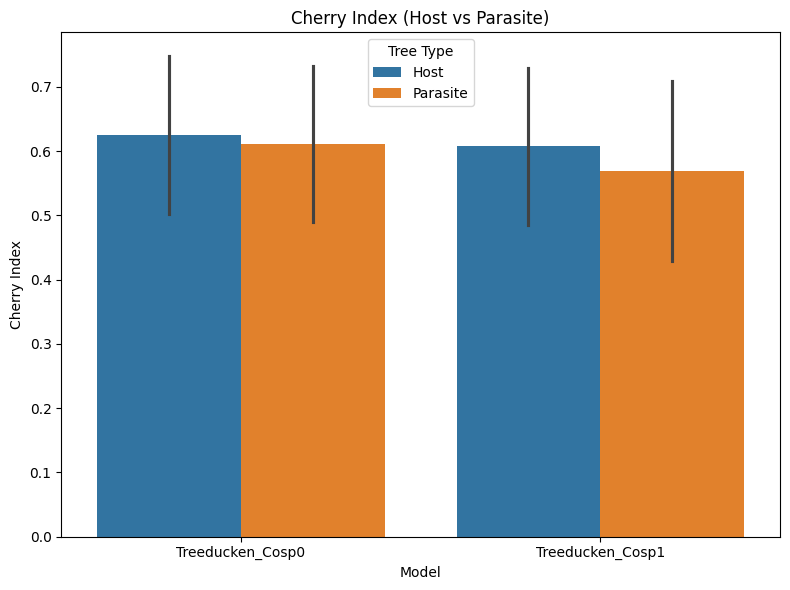

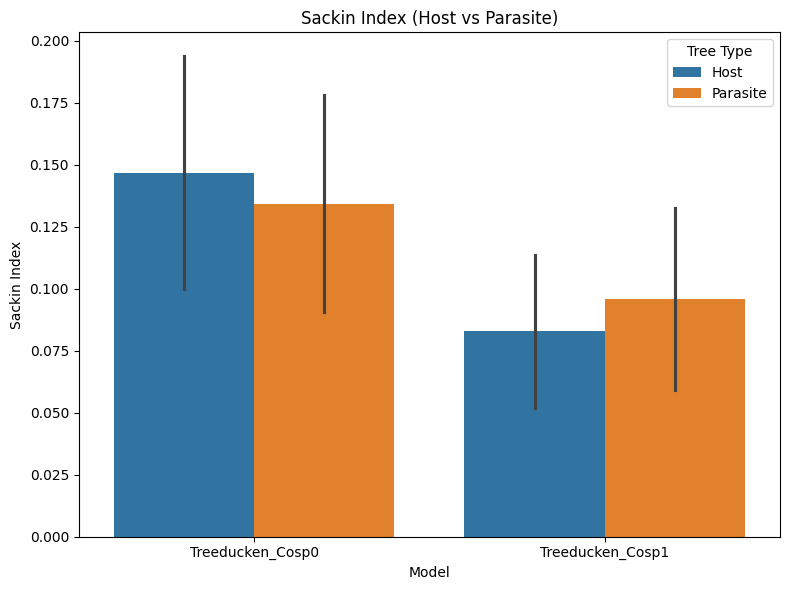

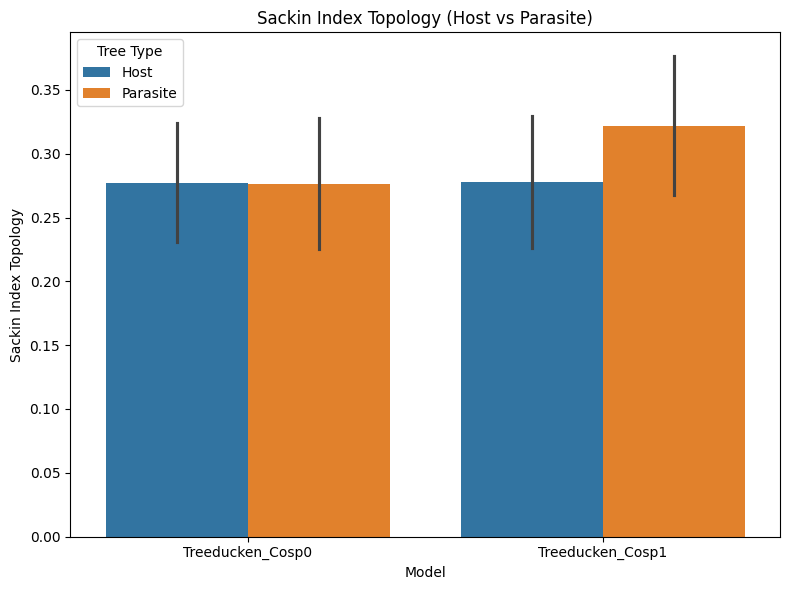

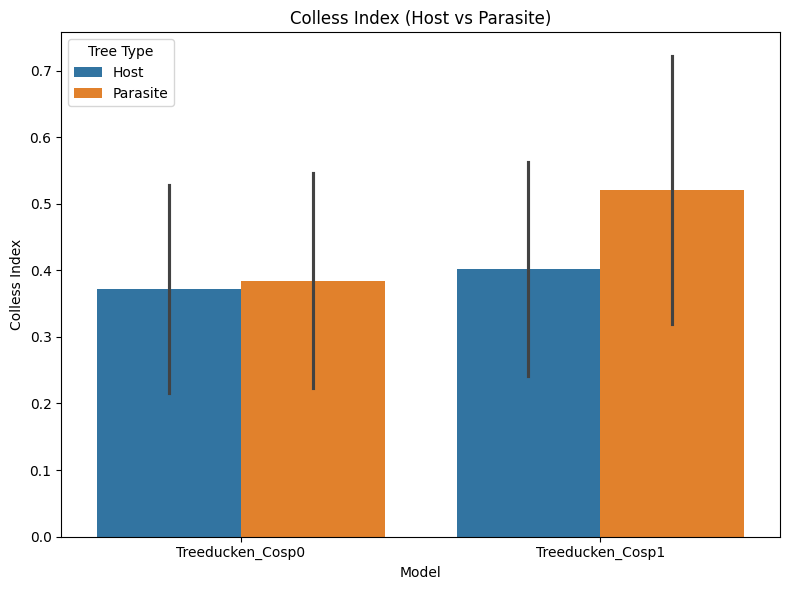

In [153]:
import openpyxl
coala_cosp_metrics = compute_tree_metrics(datasets_treeducken_cosp0, model_name="Treeducken_Cosp0")
treeducken_cosp_metrics = compute_tree_metrics(datasets_treeducken_cosp1, model_name="Treeducken_Cosp1")
comparison_metrics_cosp = pd.concat([coala_cosp_metrics, treeducken_cosp_metrics])

comparison_metrics_cosp.to_excel('comparison_metrics_cosp.xlsx', index=False)

metrics_to_plot = [
    'cherry_index_host', 'cherry_index_parasite',
    'sackin_index_host', 'sackin_index_parasite',
    'sackin_index_topology_host', 'sackin_index_topology_parasite',
    'colless_index_host', 'colless_index_parasite',
]

plot_metric_comparison_paired(comparison_metrics_cosp, 'cherry_index')
plot_metric_comparison_paired(comparison_metrics_cosp, 'sackin_index')
plot_metric_comparison_paired(comparison_metrics_cosp, 'sackin_index_topology')
plot_metric_comparison_paired(comparison_metrics_cosp, 'colless_index')

In [154]:
recon_cosp_treeducken0 = extract_sim_stats(datasets_treeducken_cosp0)
recon_cosp_treeducken1 = extract_sim_stats(datasets_treeducken_cosp1)

flattened_cosp_treeducken0 = flatten_sim_stats(recon_cosp_treeducken0).fillna(0)
flattened_cosp_treeducken1 = flatten_sim_stats(recon_cosp_treeducken1).fillna(0)



boxplot_treeducken_cosp0 = flattened_cosp_treeducken0[['filename', 'Cospeciations', 'Host_Spread_Switches', 'Symbiont_Speciations']]
boxplot_treeducken_cosp0.rename(columns={'Cospeciations': 'Cospeciation', 'Host_Spread_Switches': 'Host_switch', 'Symbiont_Speciations': 'Symbiont_Speciation'}, inplace=True)


boxplot_treeducken_cosp1 = flattened_cosp_treeducken1[['filename', 'Cospeciations', 'Host_Spread_Switches', 'Symbiont_Speciations']]
boxplot_treeducken_cosp1.rename(columns={'Cospeciations': 'Cospeciation', 'Host_Spread_Switches': 'Host_switch', 'Symbiont_Speciations': 'Symbiont_Speciation'}, inplace=True)


boxplot_treeducken_cosp0["Model"] = "Treeducken_Cosp0"
boxplot_treeducken_cosp1["Model"] = "Treeducken_Cosp1"

# Combine all models into one DataFrame
df_box_cosp = pd.concat(
    [boxplot_treeducken_cosp0, boxplot_treeducken_cosp1],
    ignore_index=True
)

# Drop NaNs (optional, keeps only rows where values exist)
df_box_cosp = df_box_cosp.dropna(subset=["Cospeciation", "Host_switch", 'Symbiont_Speciation'])

df_melted_cosp = df_box_cosp.melt(
    id_vars=["Model", "filename"],
    value_vars=["Cospeciation", "Host_switch", 'Symbiont_Speciation'],
    var_name="Event",
    value_name="Frequency"
)
df_melted_cosp

/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_3471/2958463102.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flattened_cosp_treeducken0 = flatten_sim_stats(recon_cosp_treeducken0).fillna(0)
/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_3471/2958463102.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flattened_cosp_treeducken1 = flatten_sim_stats(recon_cosp_treeducken1).fillna(0)
/var/folders/4d/nlp0vztn79z4h215lhhyfkh80000gn/T/ipykernel_3471/2958463102.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy

,Model,filename,Event,Frequency
0,Treeducken_Cosp0,Dataset830248.tgl,Cospeciation,0.0
1,Treeducken_Cosp0,Dataset596774.tgl,Cospeciation,0.0
2,Treeducken_Cosp0,Dataset680838.tgl,Cospeciation,0.0
3,Treeducken_Cosp0,Dataset560974.tgl,Cospeciation,0.0
4,Treeducken_Cosp0,Dataset147899.tgl,Cospeciation,0.0
...,...,...,...,...
3292,Treeducken_Cosp1,Dataset432636.tgl,Symbiont_Speciation,0.0
3293,Treeducken_Cosp1,Dataset886732.tgl,Symbiont_Speciation,0.0
3294,Treeducken_Cosp1,Dataset452471.tgl,Symbiont_Speciation,0.0
3295,Treeducken_Cosp1,Dataset759601.tgl,Symbiont_Speciation,0.0


In [155]:
boxplot_treeducken_cosp1

,filename,Cospeciation,Host_switch,Symbiont_Speciation,Model
0,Dataset861761.tgl,1.0,0,0,Treeducken_Cosp1
1,Dataset177437.tgl,1.0,0,0,Treeducken_Cosp1
2,Dataset84971.tgl,1.0,0,0,Treeducken_Cosp1
3,Dataset817032.tgl,1.0,0,0,Treeducken_Cosp1
4,Dataset694722.tgl,1.0,0,0,Treeducken_Cosp1
...,...,...,...,...,...
164,Dataset432636.tgl,1.0,0,0,Treeducken_Cosp1
165,Dataset886732.tgl,1.0,0,0,Treeducken_Cosp1
166,Dataset452471.tgl,1.0,0,0,Treeducken_Cosp1
167,Dataset759601.tgl,1.0,0,0,Treeducken_Cosp1


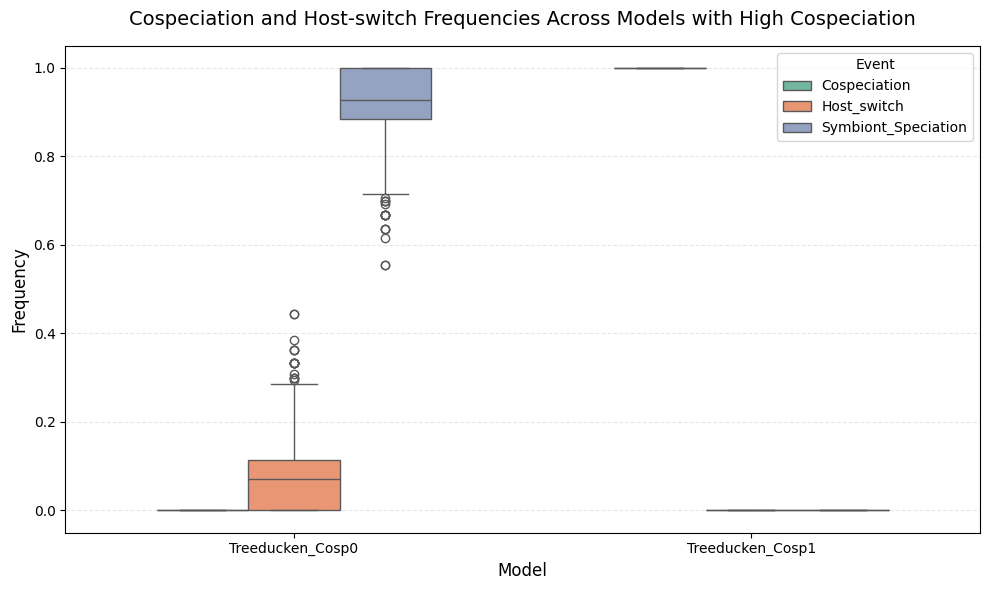

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_melted_cosp,
    x="Model",
    y="Frequency",
    hue="Event",
    palette="Set2",
    width=0.6
)

plt.title("Cospeciation and Host-switch Frequencies Across Models with High Cospeciation", fontsize=14, pad=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Event", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()